# CSDA STAC search for Evaluation Sites

Paul Montesano, PhD  
March 2026

In [1]:
pip install contextily

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib_scalebar

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import quote
import numpy as np

import sys

sys.path.append('/projects/code/csda_summaries/lib')
sys.path.append('/projects/code/geoscitools')
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
sys.path.append('/home/pmontesa/code/geoscitools')

import csdalib
import staclib

from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import importlib

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3

## Evaluation Sites

In [6]:
# Define your spreadsheet ID and sheet name
SPREADSHEET_ID = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'
BUF_KM = 1

In [7]:
SHEET_NAME = 'Evaluation Sites' # The name of the specific tab

# 2. Encode the sheet name for safe use in a URL
ENCODED_SHEET_NAME = quote(SHEET_NAME)

# 3. Construct the full URL using the gviz/tq endpoint
url = f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/gviz/tq?tqx=out:csv&sheet={ENCODED_SHEET_NAME}"

# 4. Use pandas to read the CSV data directly from the URL
try:
    sites = pd.read_csv(url)
    sites['Site Name'] = sites['Site Name abbrev'].str.rstrip()
    #sites = sites[sites['Site Name'] != 'Sicily'] # Sicily site is same as Catania
    
except Exception as e:
    print(f"An error occurred: {e}")

sites_gdf = gpd.GeoDataFrame(
        sites,
        geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
        crs="EPSG:4326"
    )
# Buffer and drop empty geoms
sites_gdf = csdalib.buffer_site_gdf(sites_gdf, BUF_KM)
sites_gdf = sites_gdf[~sites_gdf.geometry.is_empty]

# Get the list of columns to drop
cols_to_drop = sites_gdf.columns[sites_gdf.columns.str.contains('Unnamed')]
sites_gdf = sites_gdf.drop(columns=cols_to_drop)

In [8]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 70
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY + BUF_KM

In [9]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

## List CSDA STAC Collections

In [10]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open('stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 16

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | N/A |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | N/A |
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-11-21 to 2024-05-31 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | N/A |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | N/A |
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2024-01-01 to 2025-07-31 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-01-01 to 2024-12-31 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2011-01-01 to Present |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | Blacksky | blacksky | N/A |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2003-01-01 to Present |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2010-01-01 to 2025-09-29 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-01 to 2024-12-31 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-01-01 to 2025-08-15 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-01-01 to 2025-08-13 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | Unknown to Present |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-01-02 to Present |



✓ Saved to stac_collections.md


### Create site dicts for all sites

In [11]:
site_dicts = staclib.create_site_dict_from_gdf(sites_gdf, site_name_field = 'Site Name', buffer_degrees=0.1)

# Multiprocess search across all CSDA Evaluation Sites for a vendor

### Configure search

In [12]:
COLLECTION_LIST = ['satellogic']
START_OF_COMMERCIAL_ERA = '1999-01-01'
TODAY = datetime.now().strftime('%Y-%m-%d')

# START_DATE = '2010-01-01'
# END_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval

# START_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval
# END_DATE = TODAY

START_DATE = START_OF_COMMERCIAL_ERA
END_DATE = TODAY

CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

### Multiprocess search

In [15]:
search_func = partial(staclib.stac_search_site, end_date=END_DATE, start_date=START_DATE, 
                      collections=COLLECTION_LIST
                     )
#search_func = partial(search_site, today=today, start_date='2010-01-01', collections=['maxar'])

n_processes = max(1, cpu_count() - 1)
print(f"Using {n_processes} processes to search {len(CSDA_EVAL_SITE_ITEMS)} sites\n")

# Run with progress bar
with Pool(processes=n_processes) as pool:
    results = list(tqdm(
        pool.imap(search_func, CSDA_EVAL_SITE_ITEMS),
        total=len(CSDA_EVAL_SITE_ITEMS),
        desc="Searching sites"
    ))

# Collect and report results
stac_gdf_list = []
print("\nResults by site:")
for site_name, gdf, message in results:
    print(f"  {site_name}: {message}")
    if gdf is not None:
        stac_gdf_list.append(gdf)

# Combine
if stac_gdf_list:
    stac_gdf = pd.concat(stac_gdf_list, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Total: {len(stac_gdf)} items from {stac_gdf['site_name'].nunique()} sites")
    print(f"{'='*60}")
    print("\nItems per site:")
    print(stac_gdf['site_name'].value_counts())
else:
    print("\nNo items found")
    stac_gdf = gpd.GeoDataFrame()

Using 39 processes to search 473 sites



Searching sites: 100%|██████████| 473/473 [00:04<00:00, 110.94it/s]


Results by site:
  Albuquerque: Found 7 items
  Baotou: Found 8 items
  Belo Horizonte: No items found
  Boston: No items found
  Cape Town: No items found
  Casablanca: Found 12 items
  Caspian Sea: No items found
  Catania: Found 6 items
  Crater Lake: No items found
  Cuprite: No items found
  Dublin: No items found
  Gobabeb: No items found
  Hinton: No items found
  Hohhot: No items found
  King Fahd Causeway: No items found
  La Crau: No items found
  Lake Pontchartrain Causeway: Found 1 items
  London: No items found
  Melbourne: No items found
  Navarre Causeway: No items found
  Neustrelitz: No items found
  Old Bahia Bridge: No items found
  Phoenix: No items found
  PICS Algeria-3: No items found
  PICS Libya-1: No items found
  PICS Libya-4: Found 26 items
  Piedmont: No items found
  Railroad Valley: No items found
  Rio Gallegos: Found 2 items
  Rosamond: Found 2 items
  Salon-de-Provence: No items found
  Sapporo: No items found
  Suramadu Bridge: No items found
  Shadn

/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_3363982/1258326241.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_col : Removed 1 rows containing missing values.


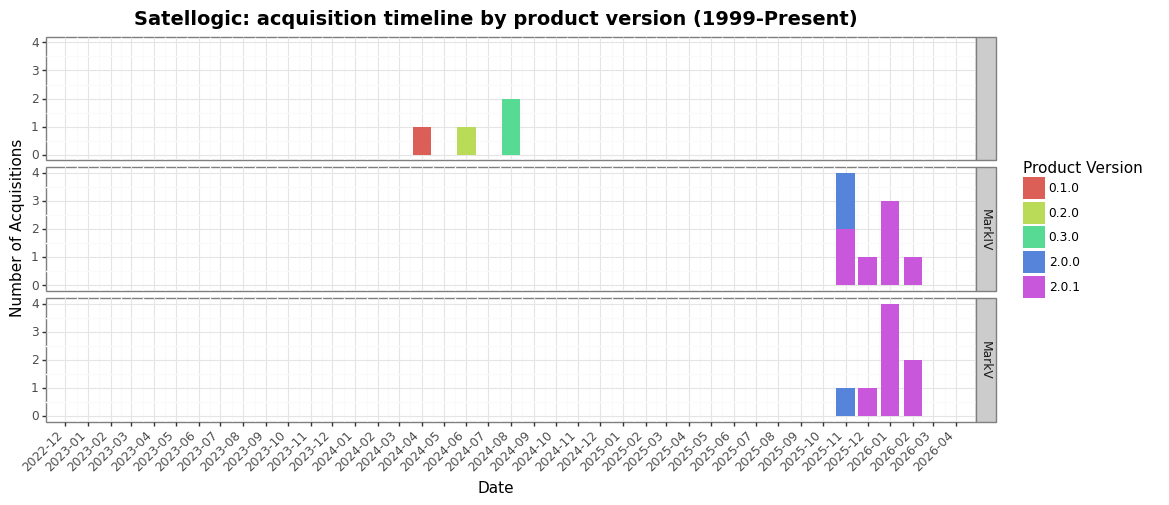

<ggplot: (1432069558983)>

In [24]:
from plotnine import *
import pandas as pd
from datetime import datetime

start_date_obj = datetime.strptime(START_DATE, '%Y-%m-%d')  # adjust format as needed

# Prepare data
plot_df = stac_gdf.copy()
plot_df.columns = plot_df.columns.str.replace(':', '_')

# Convert datetime to pandas datetime if it's a string
if plot_df['datetime'].dtype == 'object':
    plot_df['datetime'] = pd.to_datetime(plot_df['datetime'])

# Filter from 2010 onwards
plot_df = plot_df[plot_df['datetime'] >= '2020-01-01'].copy()

# Extract year-month for grouping
plot_df['year_month'] = plot_df['datetime'].dt.to_period('M').astype(str)

# Count acquisitions by year-month and version
timeline_df = plot_df.groupby(['year_month', 'satl_product_version','site_name','satl_satellite_generation']).size().reset_index(name='count')

# Convert year_month back to datetime for plotting
timeline_df['date'] = pd.to_datetime(timeline_df['year_month'])

# Define start and end dates
start_date = pd.to_datetime('2023-01-01')
end_date = timeline_df['date'].max()

# Create plot with explicit x-axis limits
p = (
    ggplot(timeline_df, aes(x='date', y='count', fill='satl_product_version')) +
    geom_col() +
    scale_x_datetime(
        limits=[start_date, end_date],
        date_breaks='1 month',
        date_labels='%Y-%m'
    ) +
    labs(
        title=f"Satellogic: acquisition timeline by product version ({start_date_obj.strftime('%Y')}-Present)",
        x='Date',
        y='Number of Acquisitions',
        fill='Product Version'
    ) +
    theme_bw() +
    theme(
        figure_size=(12, 5),
        axis_text_x=element_text(angle=45, hjust=1),
        plot_title=element_text(size=14, weight='bold')
    )
    + facet_grid('satl_satellite_generation~')
)

p

## Plot maps of sites and their acqs (static)

#### Filter for Satellogic v2 data

In [25]:
stac_gdf['satl:satellite_generation'].unique()

array(['MarkIV', 'MarkV', nan, ''], dtype=object)

In [26]:
stac_gdf['satl:product_version'].unique()

array(['2.0.1', '1.1.2', '0.3.0', '2.0.0', '0.1.0', '0.2.0'], dtype=object)

In [27]:
# Filter for version 2.*
SEARCH_STR = '2.0.'
if 'satl:product_version' in stac_gdf.columns:
    stac_gdf_v2 = stac_gdf[stac_gdf['satl:product_version'].str.startswith(SEARCH_STR, na=False)].copy()
    print(f"Filtered {len(stac_gdf)} items to {len(stac_gdf_v2)} with version {SEARCH_STR}*")
else:
    print("'satl:product_version' property not found")
    stac_gdf_v2 = stac_gdf

Filtered 72 items to 18 with version 2.0.*


## Overview map of STAC collections at evaluation sites

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).


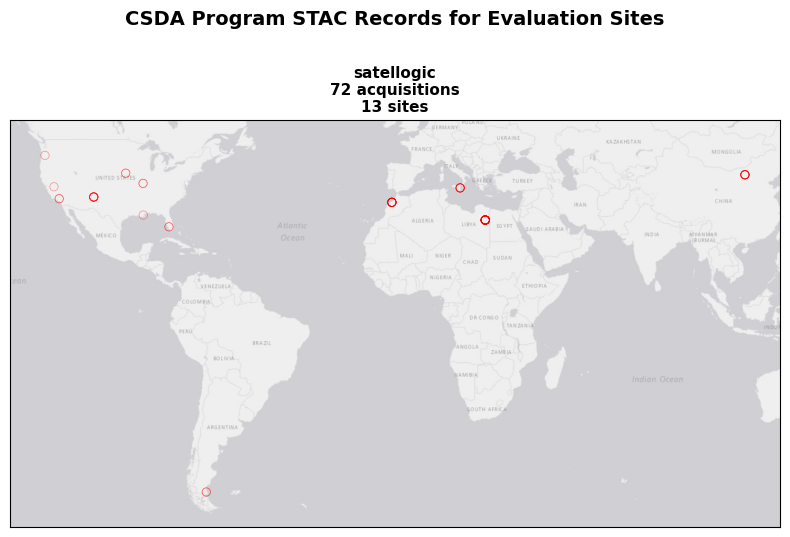

In [28]:
fig = staclib.plot_collections_map(stac_gdf, show_stats=True)
plt.show()

### Plot site maps for Satellogic v2 acquisitions

Plotting 2 acquisitions for Albuquerque
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for Baotou
Found 0 additional acquisitions in buffer zone
Plotting 1 acquisitions for CA Yosemite 3
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for Casablanca
Found 0 additional acquisitions in buffer zone
Plotting 1 acquisitions for Catania
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for FL Southwest 3
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for NE Post Spring Flood 6
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for PICS Libya-4
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for Rio Gallegos
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for Rosamond
Found 0 additional acquisitions in buffer zone


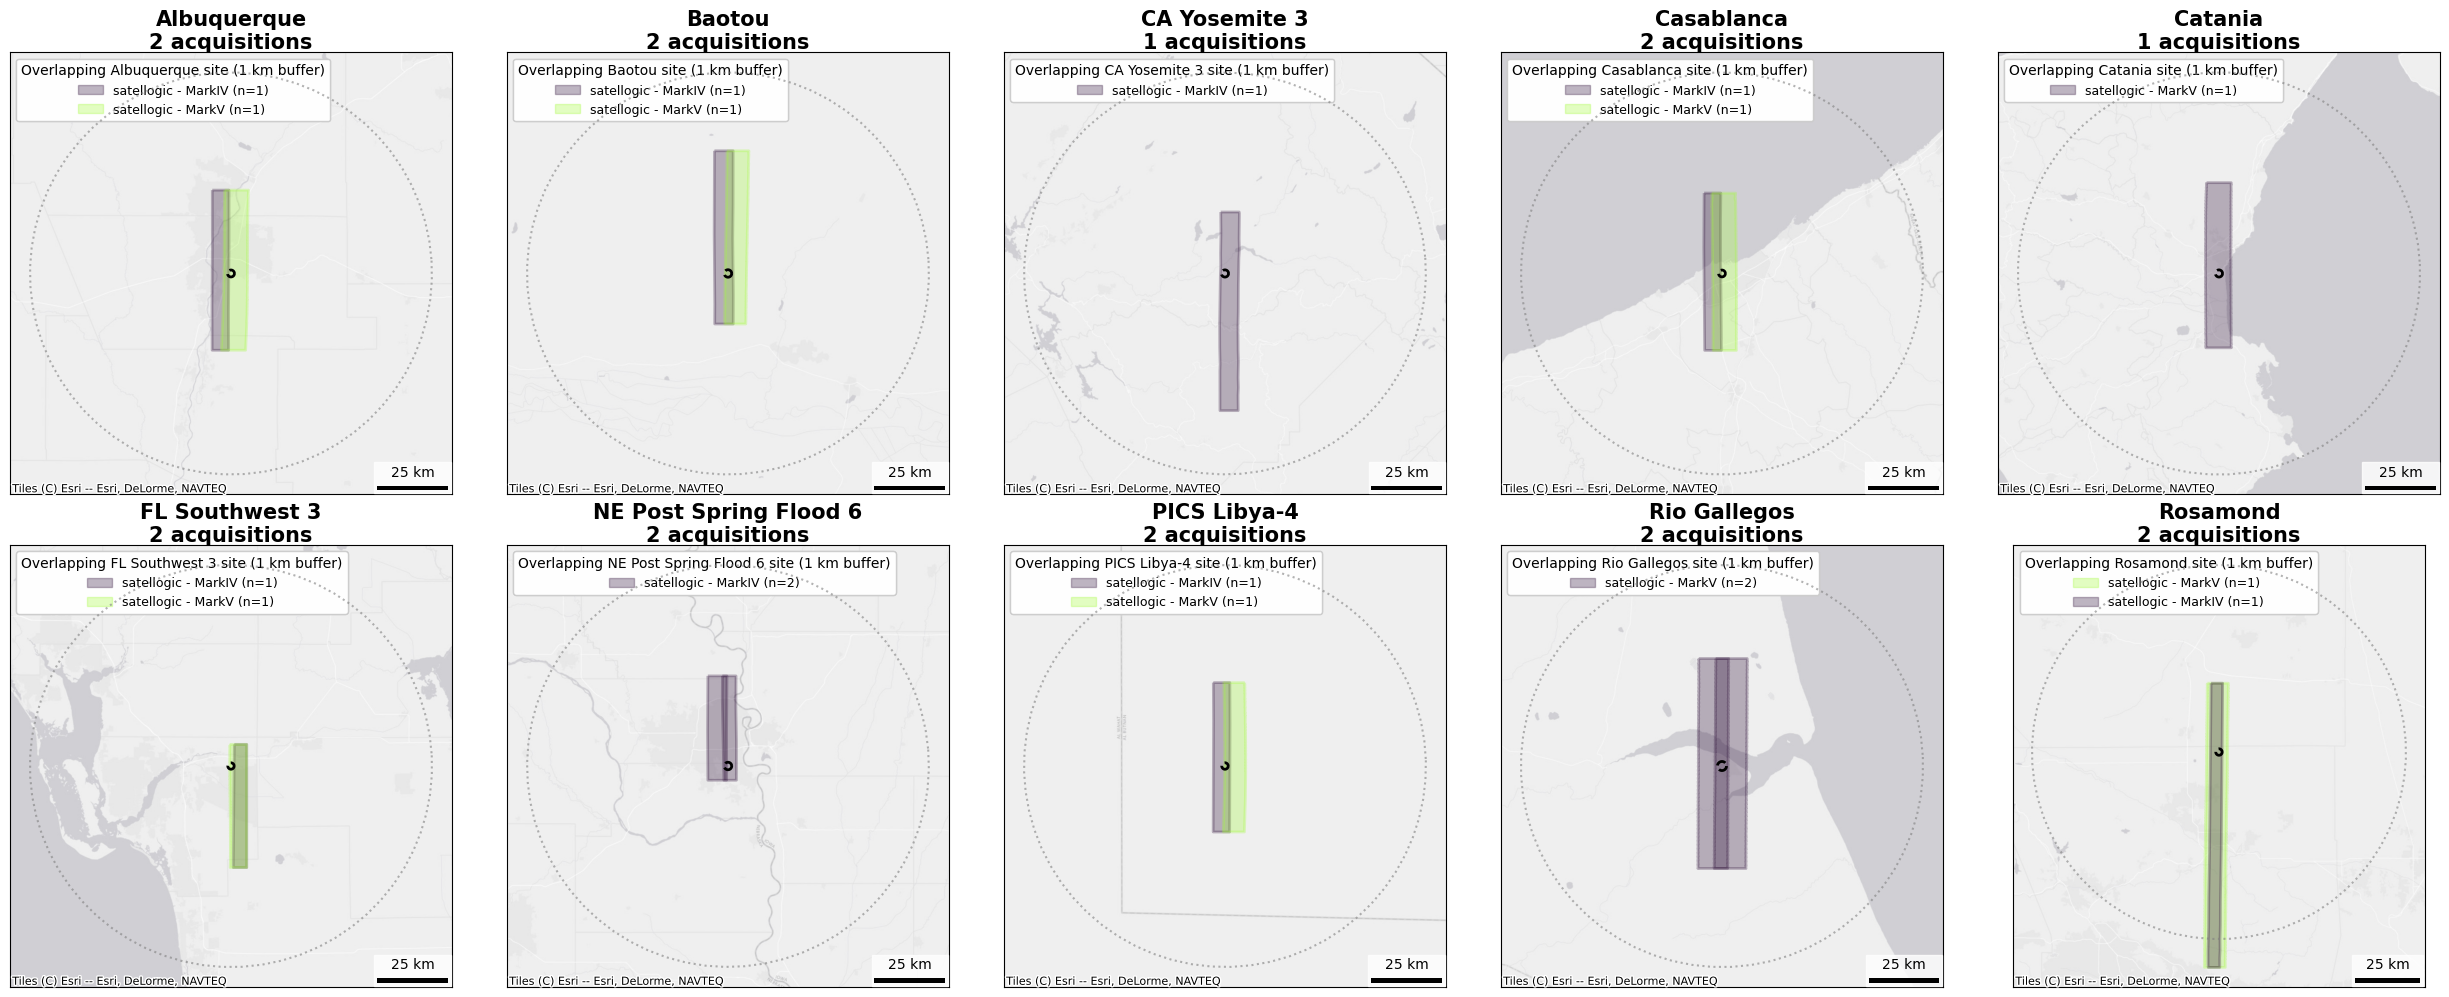

In [29]:
# Define gdf to plot
gdf_to_plot = stac_gdf_v2

# Define sites to plot
sites_to_plot = sorted([site for site in gdf_to_plot.site_name.unique() if site != 'Not CSDA Eval Site'])

# Create grid
n_sites = len(sites_to_plot)
n_cols = 5
n_rows = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols,5 * n_rows))

# Flatten axes
if n_sites == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plot each site
for idx, site_name in enumerate(sites_to_plot):
    csdalib.plot_site_coverage(site_name, 
                      gdf_to_plot, 
                      sites_gdf, 
                      BUF_KM, 
                       BUF_KM_TOTAL_FOR_DISPLAY,
                      sites_buf_gdf=sites_gdf_buf_display,
                      site_name_field = 'site_name',
                               
                        # Satellogic
                        id_field = 'id', 
                        affiliation_field = 'collection',
                        constellation_field = 'satl:satellite_generation',
                               
                      ax=axes[idx])  # Pass the axis here

# Hide unused subplots
for idx in range(n_sites, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Heatmaps provides info on amount of overlap at a site

#### static, all sites for each collection

Calculating global count range...
Global count range: 1 - 2


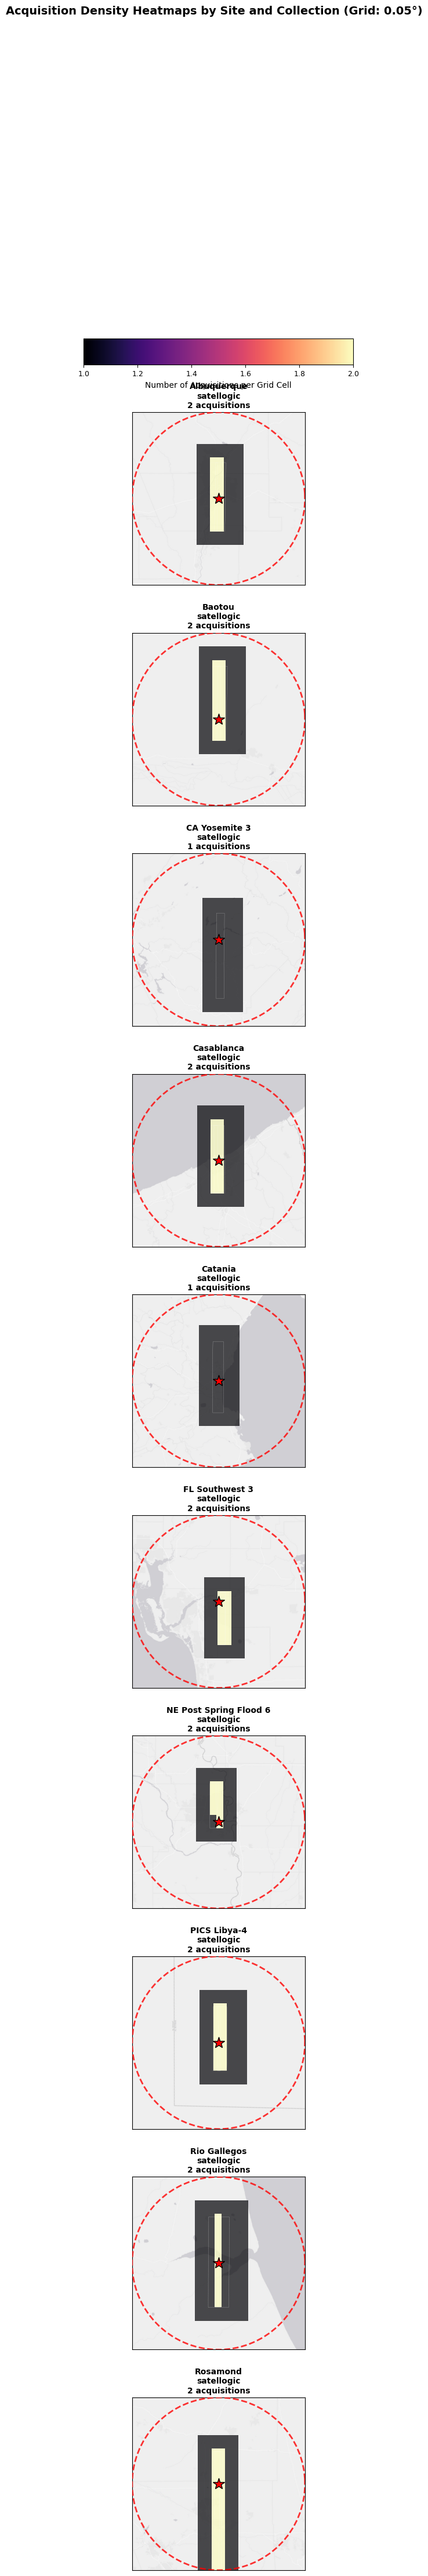

In [30]:
# Use it
all_grids, fig = staclib.create_acquisition_heatmap_multi(
    stac_gdf_v2,
    sites_gdf,
    sites_gdf_buf_display,
    site_name_field='site_name',
    site_name_field_sites='Site Name',
    # collections=['planet', 'satellogic'],
    # sites=['PICS Libya-4', 'Casablanca'],
    collections=['satellogic'],
    sites=None,
    grid_size=0.05,
    cmap='magma'
)

plt.show()

#### interactive for 1 site, collection

In [31]:
m, grid_gdf = staclib.create_interactive_heatmap(
    stac_gdf_v2,
    collection_name='satellogic',
    grid_size=0.01,
    cmap='magma',
    site_name='Casablanca'
)

# m.save('libya4_satellogic_heatmap.html')
m

Creating heatmap for 2 acquisitions
Grid cells with data: 690
Acquisition count range: 1 - 2


## Read an image on-the-fly and plot

In [35]:
stac_gdf.filter(like='asset').columns

Index(['asset_cloud_href', 'asset_cloud_type', 'asset_visual_href',
       'asset_visual_type', 'asset_preview_href', 'asset_preview_type',
       'asset_analytic_href', 'asset_analytic_type', 'asset_footprint_href',
       'asset_footprint_type', 'asset_thumbnail_href', 'asset_thumbnail_type',
       'asset_vrt_cloud_href', 'asset_vrt_cloud_type', 'asset_vrt_visual_href',
       'asset_vrt_visual_type', 'asset_toa-factors_href',
       'asset_toa-factors_type', 'asset_vrt_analytic_href',
       'asset_vrt_analytic_type', 'asset_xml-metadata_href',
       'asset_xml-metadata_type', 'asset_visual-overview_href',
       'asset_visual-overview_type', 'asset_geojson-metadata_href',
       'asset_geojson-metadata_type', 'asset_analytic-overview_href',
       'asset_analytic-overview_type', 'asset_solar-and-viewing-angles_href',
       'asset_solar-and-viewing-angles_type'],
      dtype='object')

In [39]:
stac_gdf.asset_vrt_analytic_href.to_list()

['s3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2026/01/10/20260110_175204_412_SN37_L1D_SR_MS_337320/rasters/20260110_175204_412_SN37_L1D_SR_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2026/01/06/20260106_213029_312_SN46_L1D_SR_MS_337320/rasters/20260106_213029_312_SN46_L1D_SR_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2024/11/05/20241105_180508_SN50_L1D_MS_252680/rasters/20241105_180508_SN50_L1D_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2024/09/23/20240923_180910_SN50_L1D_MS_245154/rasters/20240923_180910_SN50_L1D_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2024/09/23/20240923_180612_SN48_L1D_MS_245154/rasters/20240923_180612_SN48_L1D_MS_TOA_0.tif',
 's3://ss-in